#Predicting Train Delays in Saudi Arabia: A Data-Driven Approach

In [1]:
# === IMPORTS ===
# === CLEAN IMPORTS ===

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.io as pio

# Stats and distributions
import scipy.stats as stats
from scipy.stats import randint, uniform

# Scikit-learn - Model selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    cross_val_predict
)

# Scikit-learn - Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# XGBoost & LightGBM
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics & evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Inspection
from sklearn.inspection import permutation_importance


pio.renderers.default = 'notebook'

# LOAD Main Train DATA ===
main_df = pd.read_csv("maindata.csv")
main_df['Date'] = pd.to_datetime(main_df['Date'], format="%m/%d/%Y", errors='coerce')
main_df['Departure_City'] = main_df['Direction'].str.split(" - ").str[0].str.strip()



In [2]:
# === MERGE Files ===
#1.MERGE WEATHER DATA
city_weather_files = {
    "Riyadh": "weather_Riyadh.csv",
    "Qassim": "weather_Qassim.csv",
    "Hail": "weather_Hail.csv",
    "Al Qurriyat": "weather_Al Qurriyat.csv",
    "Dammam": "weather_Dammam.csv",
    "Hufof": "weather_Hufof.csv"
}

merged_chunks = []
for city, weather_file in city_weather_files.items():
    weather_df = pd.read_csv(weather_file)
    weather_df['Date'] = pd.to_datetime(weather_df['Date'], format="%m/%d/%Y", errors='coerce')
    weather_df['Departure_City'] = city
    city_df = main_df[main_df['Departure_City'] == city]
    merged_city_df = pd.merge(city_df, weather_df, how='left', on=['Date', 'Departure_City'])
    merged_chunks.append(merged_city_df)

merged_df = pd.concat(merged_chunks, ignore_index=True)

# 2.MERGE HOLIDAY DATA ===
holiday_df = pd.read_csv("saudi_holidays.csv")
holiday_df.columns = holiday_df.columns.str.strip()
holiday_df['Date'] = pd.to_datetime(holiday_df['Date'], format="%m/%d/%Y", errors='coerce')
holiday_df['is_holiday'] = 1

merged_df = pd.merge(
    merged_df,
    holiday_df[['Date', 'is_holiday', 'Vacation Type']],
    how='left',
    on='Date'
)

merged_df['is_holiday'] = merged_df['is_holiday'].fillna(0).astype(int)
merged_df['Vacation Type'] = merged_df['Vacation Type'].fillna('None')

In [3]:
# === BASIC EDA CHECKS ===
print("Missing values per column:")
print(merged_df.isnull().sum())

print("\nTarget class distribution:")
print(merged_df['Right time'].value_counts())

Missing values per column:
DAY                           0
Date                          0
TID                          20
Direction                     0
10 PPM                       40
6-10 mins                    40
1-5 mins                     40
Right time                   40
Journey time                 52
month                         0
year                          0
Week Number                   0
Line                          0
sub direction                 1
Departure_City                0
City                          4
weather_code (wmo code)       4
temperature_2m_mean (°C)      4
rain_sum (mm)                 4
precipitation_sum (mm)        4
precipitation_hours (h)       4
wind_speed_10m_max (km/h)     4
wind_gusts_10m_max (km/h)     4
is_holiday                    0
Vacation Type                 0
dtype: int64

Target class distribution:
Right time
YES    10905
NO      4005
Name: count, dtype: int64


In [4]:
# === Preprocessing ===

# 1. HANDLE TARGET ===

# Drop rows with missing target
merged_df = merged_df[merged_df['Right time'].notna()]

# Convert 'Journey time' to minutes
def convert_to_minutes(time_str):
    try:
        parts = time_str.split(':')
        return int(parts[0]) * 60 + int(parts[1])
    except:
        return None

merged_df['Journey_time_min'] = merged_df['Journey time'].apply(convert_to_minutes)

# 2.Impute missing journey time ===
avg_journey_by_direction = merged_df.groupby('Direction')['Journey_time_min'].mean()

def impute_journey(row):
    if pd.isna(row['Journey_time_min']):
        return avg_journey_by_direction.get(row['Direction'], None)
    return row['Journey_time_min']

merged_df['Journey_time_min'] = merged_df.apply(impute_journey, axis=1)

# Convert back to HH:MM if needed
def convert_to_hhmm(minutes):
    if pd.isna(minutes):
        return None
    hours = int(minutes) // 60
    mins = int(minutes) % 60
    return f"{hours}:{mins:02d}"

merged_df['Journey time'] = merged_df['Journey_time_min'].apply(convert_to_hhmm)

#3. Map Weather Code to acctual label
weather_code_map ={
0: "Clear sky",
1: "Mainly clear",
2: "Partly cloudy",
3: "Overcast",
45: "Fog",
48: "Depositing rime fog",
51: "Light drizzle",
53: "Moderate drizzle",
55: "Dense drizzle",
56: "Freezing light drizzle",
57: "Freezing dense drizzle",
61: "Slight rain",
63: "Moderate rain",
65: "Heavy rain",
66: "Freezing rain (light)",
67: "Freezing rain (heavy)",
71: "Slight snow",
73: "Moderate snow",
75: "Heavy snow",
77: "Snow grains",
80: "Slight rain showers",
81: "Moderate rain showers",
82: "Violent rain showers",
85: "Slight snow showers",
86: "Heavy snow showers",
95: "Thunderstorm",
96: "Thunderstorm with slight hail",
99: "Thunderstorm with heavy hail"
}


merged_df['Weather_Description'] = merged_df['weather_code (wmo code)'].map(weather_code_map)


# 4.FEATURE ENGINEERING ===

# 4.1. Departure City
merged_df['Departure_City'] = merged_df['Direction'].str.split(" - ").str[0].str.strip()

# 4.2. Arrival City
merged_df['Arrival_City'] = merged_df['Direction'].str.split(" - ").str[1].str.strip()

# 4.3. Weekend Indicator
merged_df['Weekend'] = merged_df['DAY'].isin(['Friday', 'Saturday']).astype(int)

# 4.4. > 10 min Delay Column (inverted logic from 10 PPM)
merged_df['> 10 min'] = merged_df['10 PPM '].map(lambda x: 'NO' if str(x).strip().upper() == 'YES' else 'YES')

# 4.5.Season 
merged_df['month'] = merged_df['Date'].dt.month

def assign_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    return 'Unknown'

merged_df['Season'] = merged_df['month'].apply(assign_season)


# 5. Initial Inspection
print("\n First few rows after merging and feature engineering:")
print(merged_df.head())
print(" Missing Values:\n", merged_df.isnull().sum())
print("\n Target Class Distribution:\n", merged_df['Right time'].value_counts())



#6.Save merged cleaned data
merged_df.to_csv("merged_preprocessed_data.csv", index=False)
print("✅ Preprocessed dataset saved as 'merged_preprocessed_data.csv'")


 First few rows after merging and feature engineering:
      DAY       Date       TID        Direction 10 PPM  6-10 mins 1-5 mins  \
0  Sunday 2023-01-01  111400.0    Riyadh - Hail     YES        NO       NO   
1  Sunday 2023-01-01  211300.0  Riyadh - Qassim      NO        NO       NO   
2  Sunday 2023-01-01  211301.0  Riyadh - Qassim     YES        NO       NO   
3  Monday 2023-01-02  111400.0    Riyadh - Hail     YES        NO       NO   
4  Monday 2023-01-02  211300.0  Riyadh - Qassim     YES        NO       NO   

  Right time Journey time  month  ...  wind_speed_10m_max (km/h)  \
0        YES         4:27      1  ...                       13.8   
1         NO         3:13      1  ...                       13.8   
2        YES         2:26      1  ...                       13.8   
3        YES         4:29      1  ...                       11.9   
4        YES         2:25      1  ...                       11.9   

   wind_gusts_10m_max (km/h) is_holiday Vacation Type Journey_time

In [5]:
#===EDA===
#1.Dataset overview
print("Dataset structure:")
print(merged_df.info())

#2. Numerical Features Overview:Select only continuous numerical features (exclude IDs, categorical encodings, and binary indicators)
true_numerical_cols = [
    'temperature_2m_mean (°C)', 'rain_sum (mm)', 'precipitation_sum (mm)',
    'precipitation_hours (h)', 'wind_speed_10m_max (km/h)',
    'wind_gusts_10m_max (km/h)', 'Journey_time_min'
]

print("\n Summary statistics for true continuous numerical features:")
print(merged_df[true_numerical_cols].describe().T.sort_index())

#3.Catagorical Features Overiview
true_cat_cols = merged_df.select_dtypes(include='object').columns.tolist()


print("\n Unique value counts for categorical columns:")
for col in true_cat_cols:
    print(f"{col}: {merged_df[col].nunique()} unique values")
    
#4. Operational Data Insights
# 4.1. Total unique train IDs
total_trains = merged_df['TID'].nunique()
print(f" Total number of unique trains considered: {total_trains}")

# 4.2. Average trains running per calendar day
avg_trains_per_date = merged_df.groupby('Date').size().mean()
print(f" Average number of trains per calendar day: {avg_trains_per_date:.2f}")


# 4.3. Average number of trains running on each day of the week
avg_trains_by_day = (
    merged_df.groupby(['DAY', 'Date']).size().groupby('DAY').mean().sort_values()
)

print("\nAverage number of trains per day of week:")
print(avg_trains_by_day)


#4.5.Journey time insights
# Journey time extremes in HH:MM format

longest = int(merged_df['Journey_time_min'].max())

def format_minutes(minutes):
    return f"{minutes // 60}:{minutes % 60:02d}"


print(f" Longest journey time: {format_minutes(longest)} (hh:mm)")

# 4.6 Average journey time per direction (in hh:mm)
avg_journey_by_dir = merged_df.groupby('Direction')['Journey_time_min'].mean().dropna()

# Format to hh:mm
avg_journey_by_dir_formatted = avg_journey_by_dir.apply(lambda x: f"{int(x)//60}:{int(x)%60:02d}")

print("\n Average journey time per direction (hh:mm):")
print(avg_journey_by_dir_formatted.sort_values())

#4.7.Direction frequency insights
direction_counts = merged_df['Direction'].value_counts()

most_common_direction = direction_counts.idxmax()
least_common_direction = direction_counts.idxmin()

print(f"\n Most frequent train direction: {most_common_direction} ({direction_counts.max()} trips)")
print(f" Least frequent train direction: {least_common_direction} ({direction_counts.min()} trips)")


Dataset structure:
<class 'pandas.core.frame.DataFrame'>
Index: 14910 entries, 0 to 14949
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   DAY                        14910 non-null  object        
 1   Date                       14910 non-null  datetime64[ns]
 2   TID                        14910 non-null  float64       
 3   Direction                  14910 non-null  object        
 4   10 PPM                     14910 non-null  object        
 5   6-10 mins                  14910 non-null  object        
 6   1-5 mins                   14910 non-null  object        
 7   Right time                 14910 non-null  object        
 8   Journey time               14910 non-null  object        
 9   month                      14910 non-null  int32         
 10  year                       14910 non-null  int64         
 11  Week Number                14910 non-null  int64     

C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




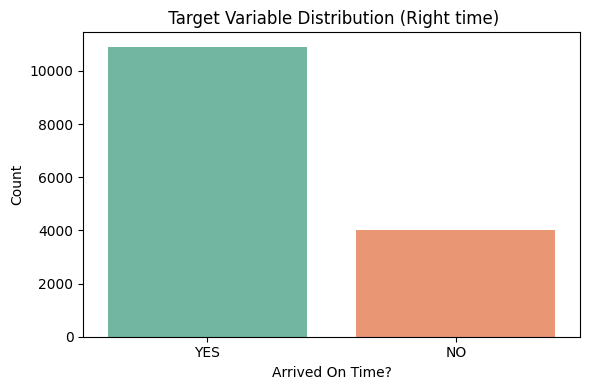

C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




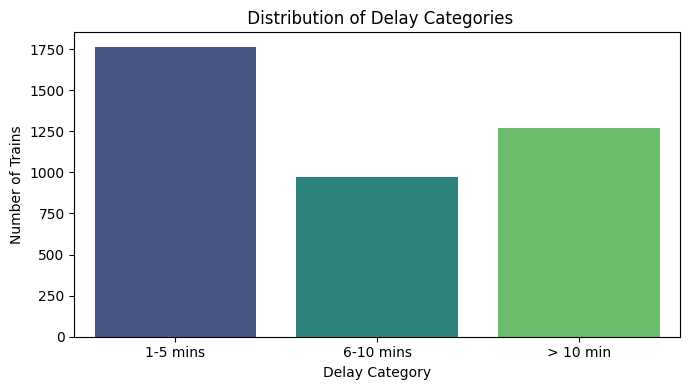

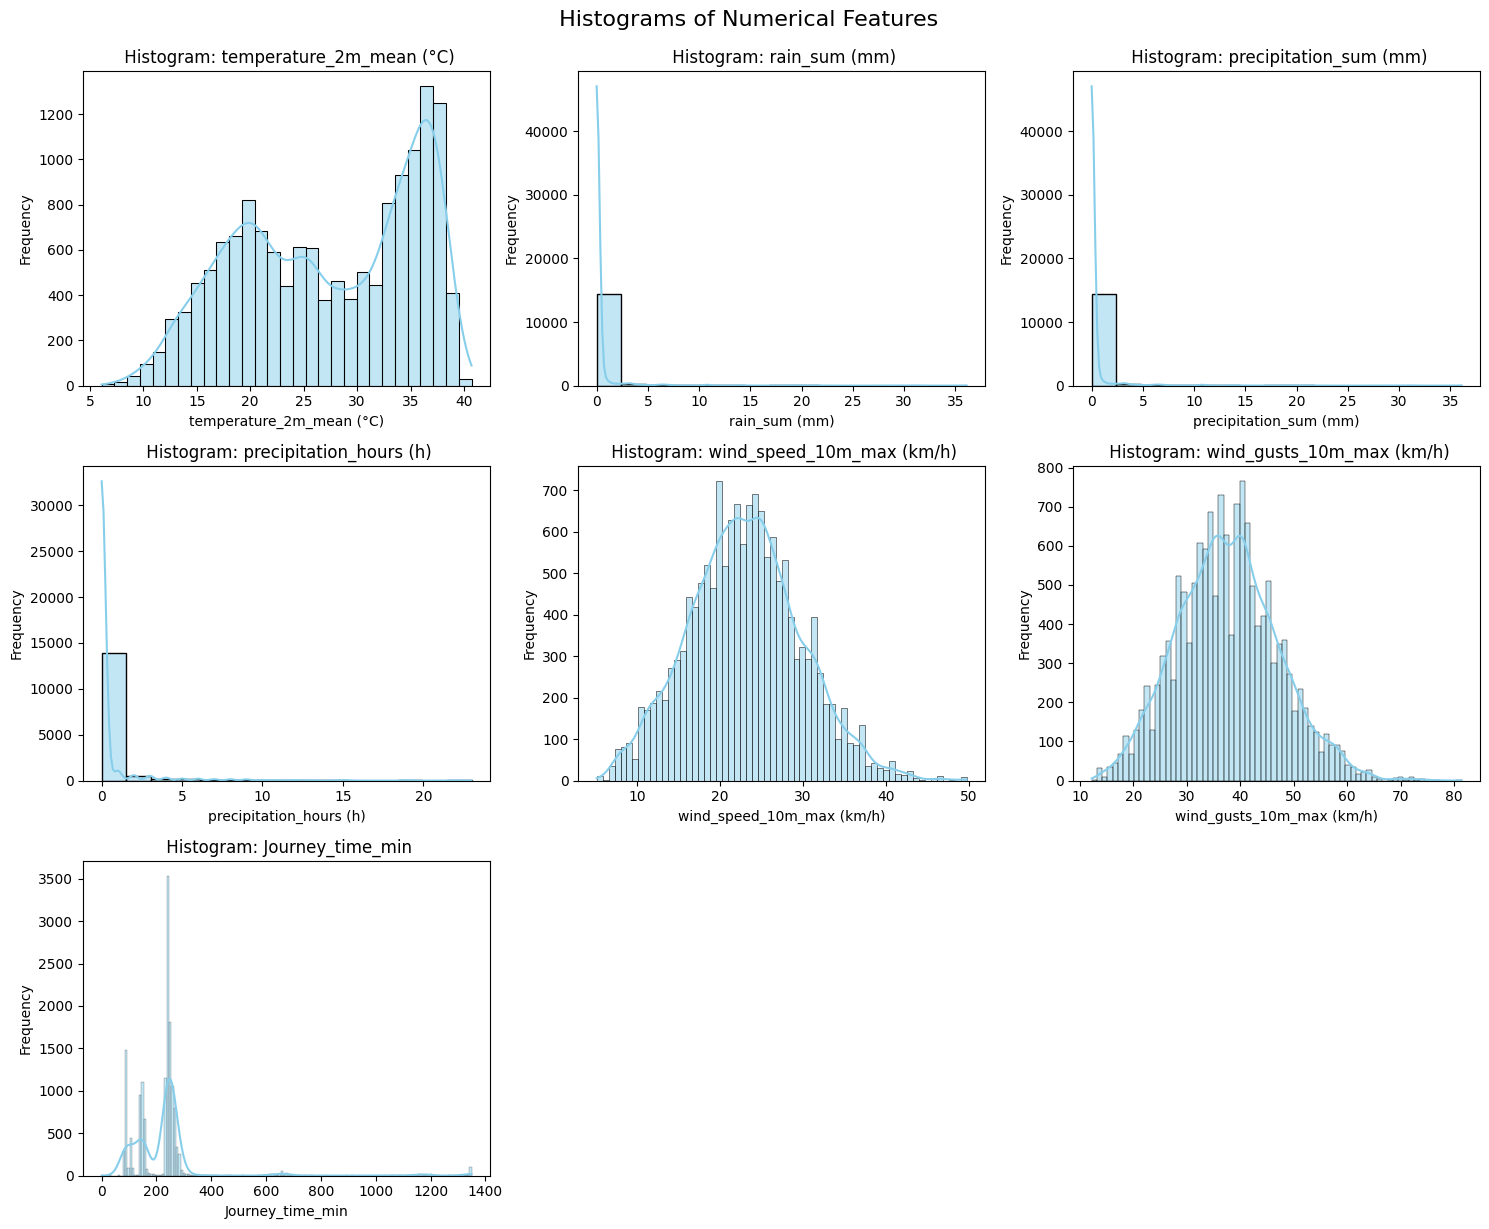

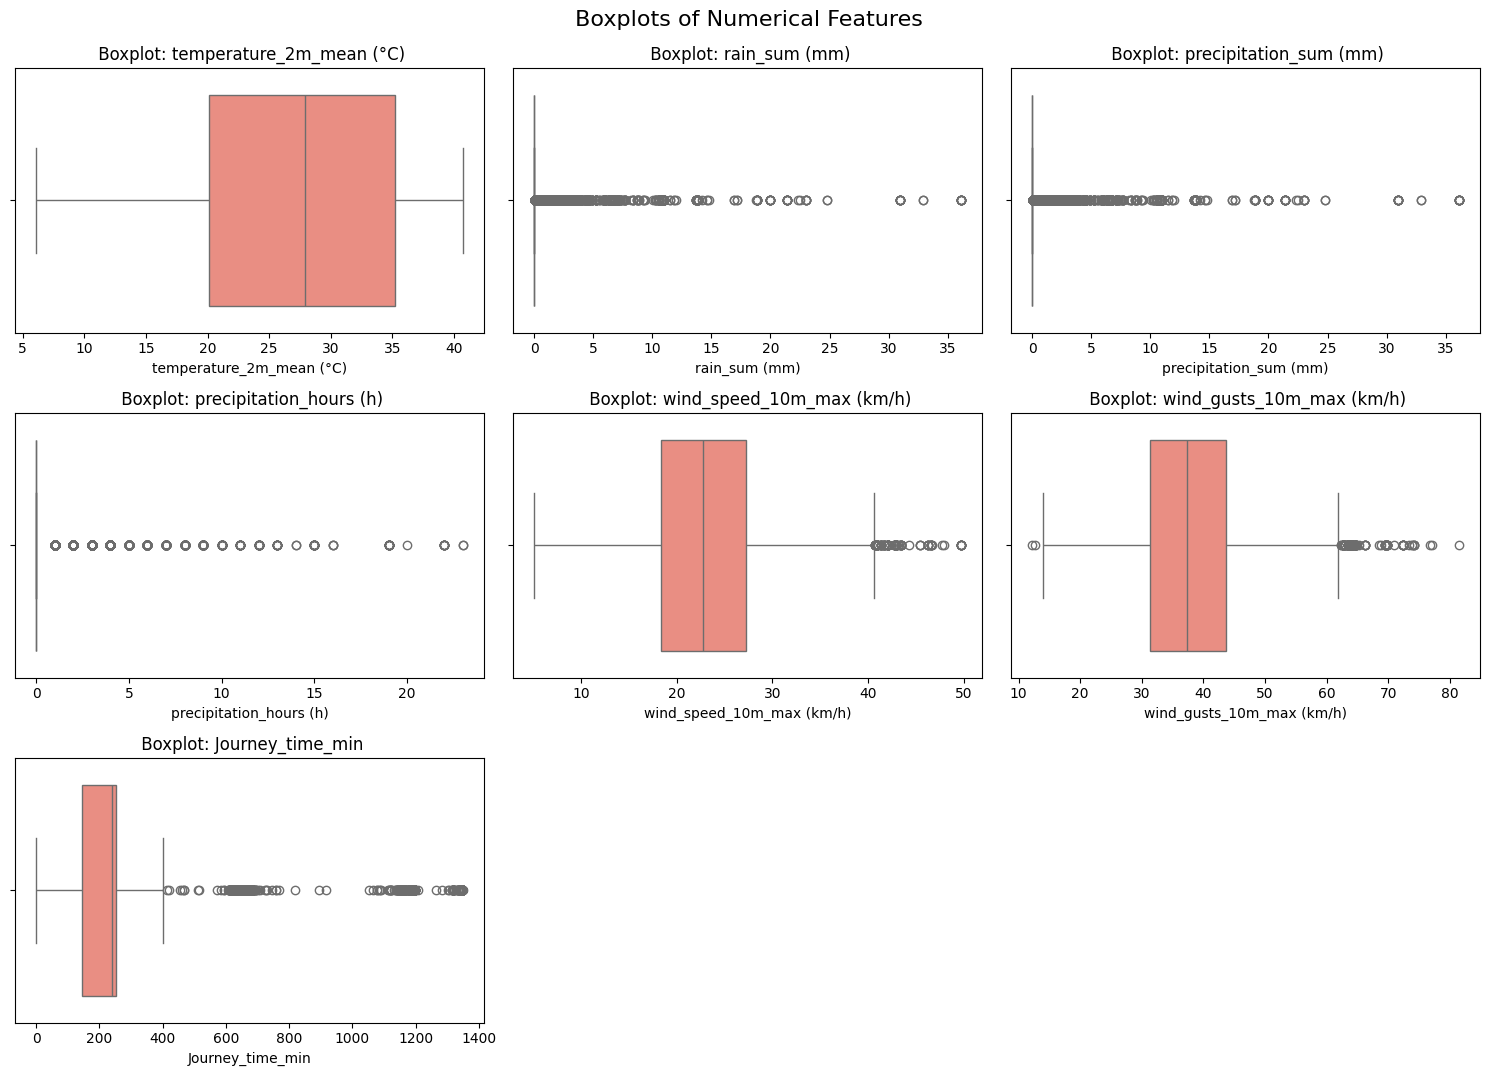

C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:78: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:78: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:78: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:78: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same ef

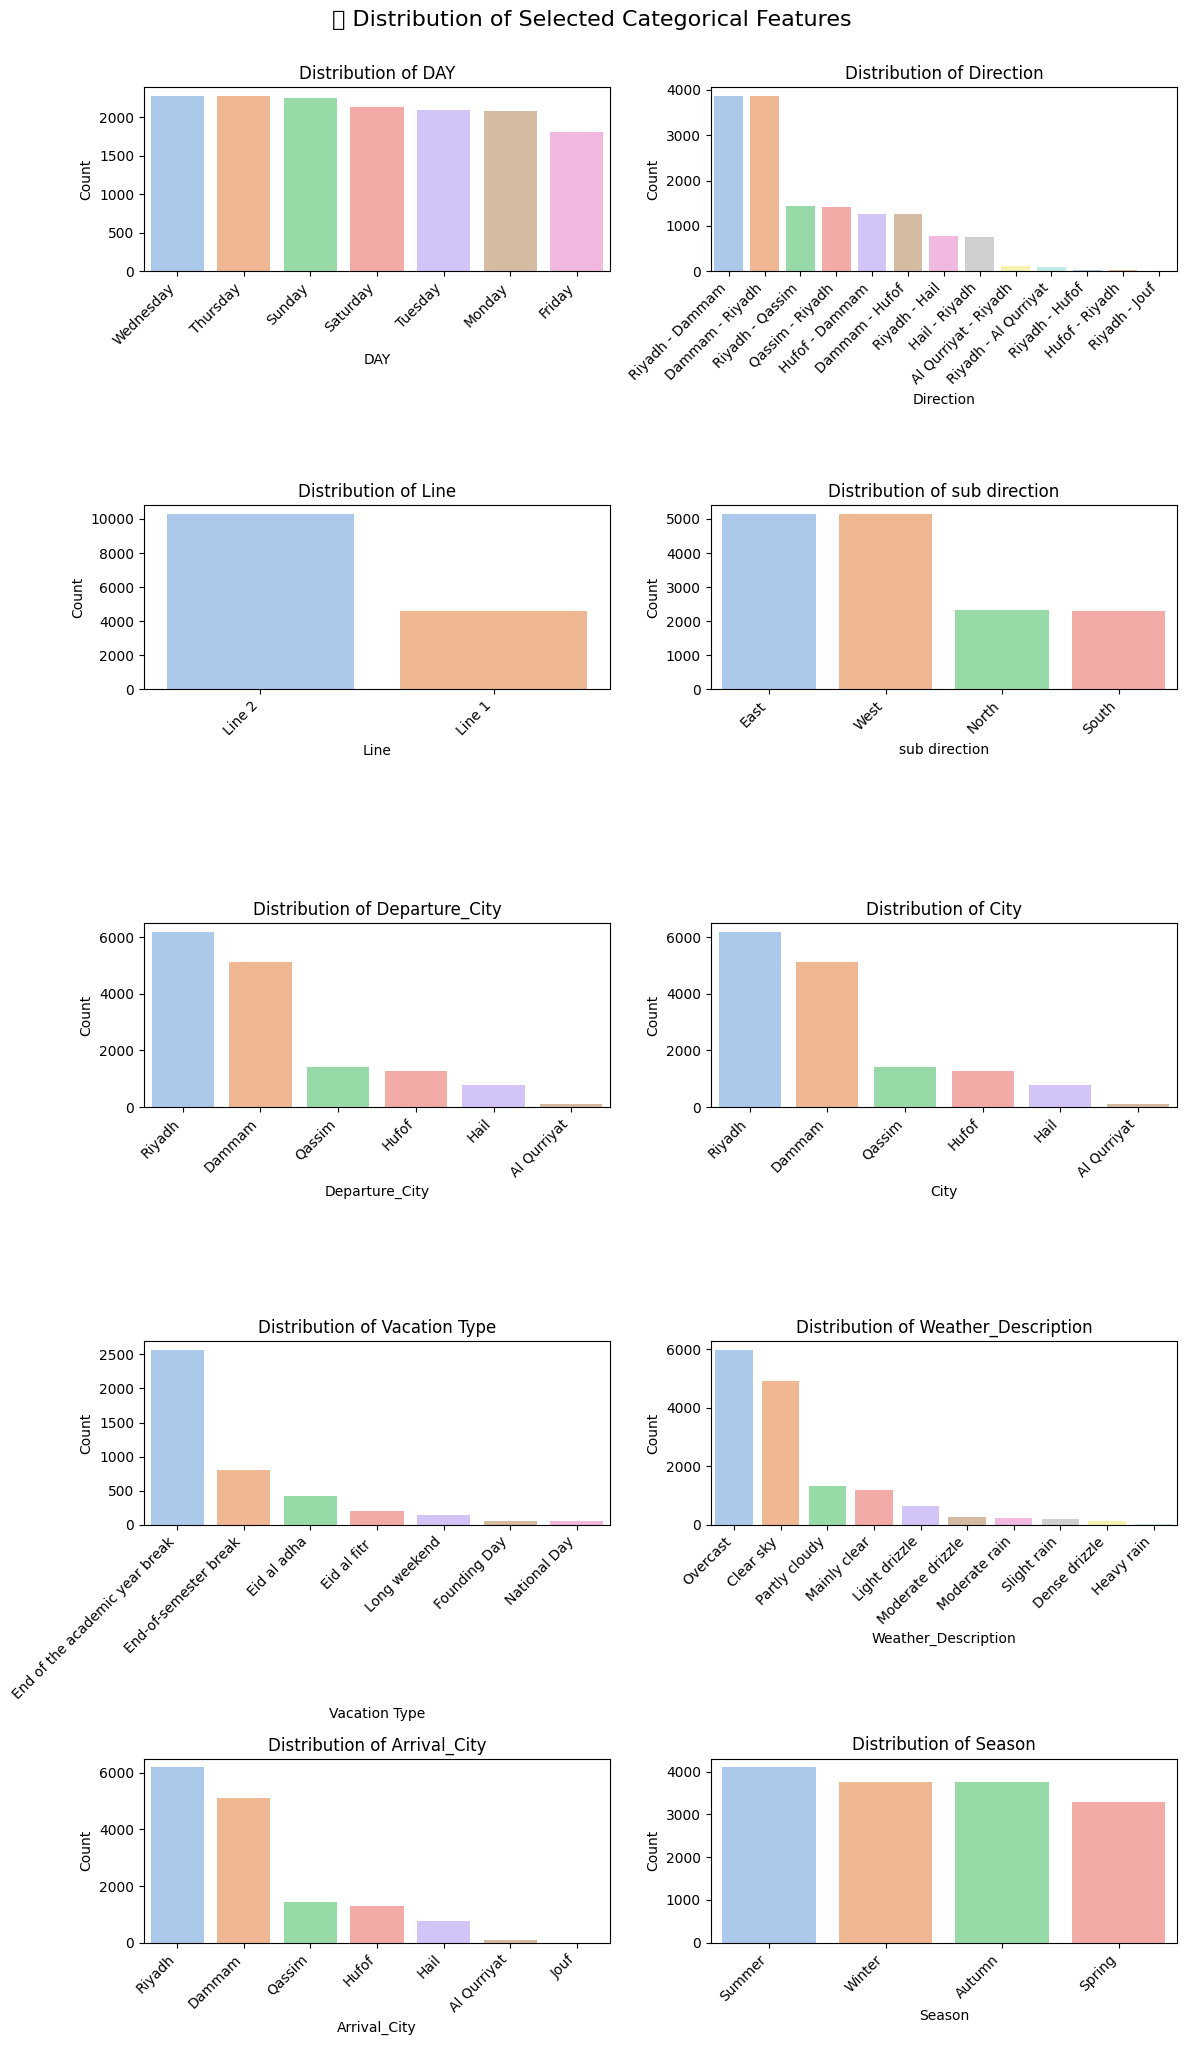

C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:107: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:111: UserWarning:

Glyph 9201 (\N{STOPWATCH}) missing from current font.

C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning:

Glyph 9201 (\N{STOPWATCH}) missing from current font.



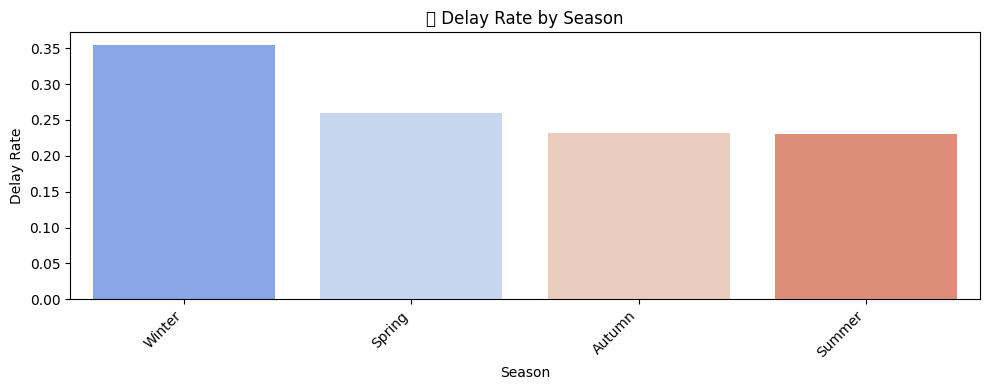

C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:107: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:111: UserWarning:

Glyph 9201 (\N{STOPWATCH}) missing from current font.

C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning:

Glyph 9201 (\N{STOPWATCH}) missing from current font.



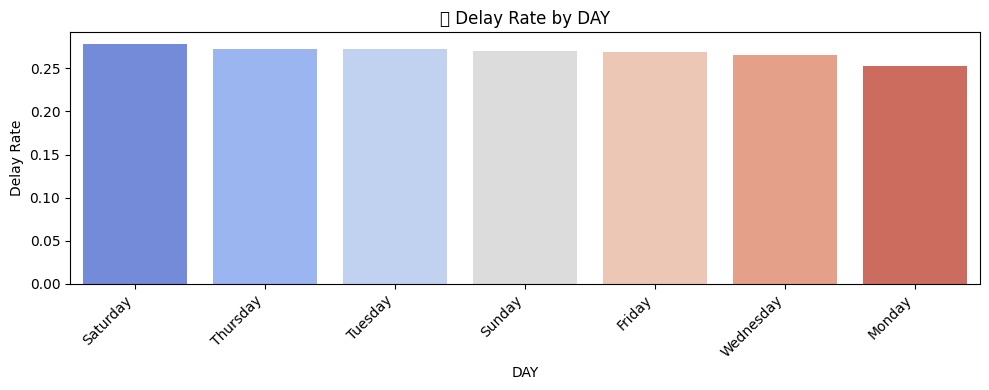

C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:107: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:111: UserWarning:

Glyph 9201 (\N{STOPWATCH}) missing from current font.

C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning:

Glyph 9201 (\N{STOPWATCH}) missing from current font.



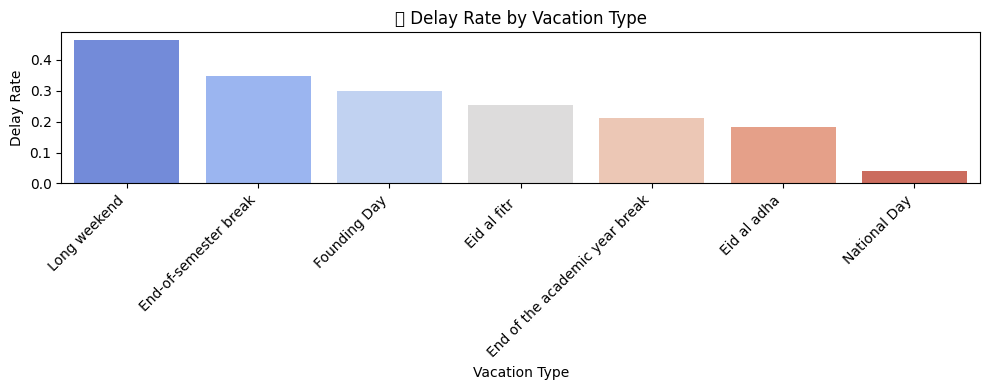

C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:107: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:111: UserWarning:

Glyph 9201 (\N{STOPWATCH}) missing from current font.

C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning:

Glyph 9201 (\N{STOPWATCH}) missing from current font.



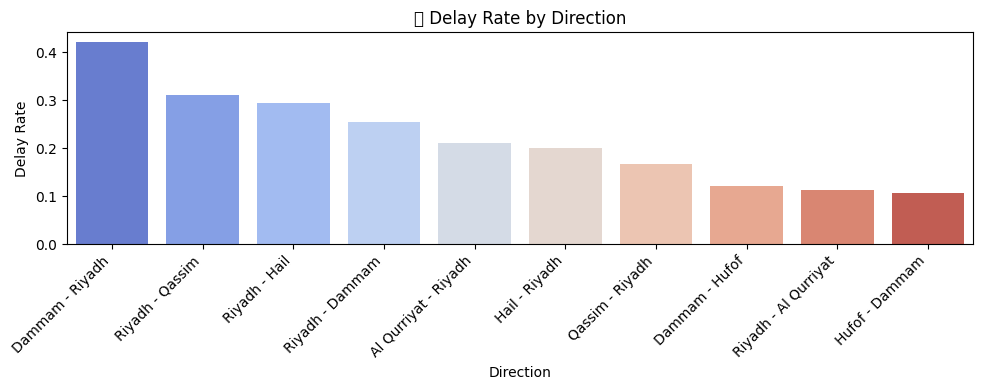

C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:107: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:111: UserWarning:

Glyph 9201 (\N{STOPWATCH}) missing from current font.

C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning:

Glyph 9201 (\N{STOPWATCH}) missing from current font.



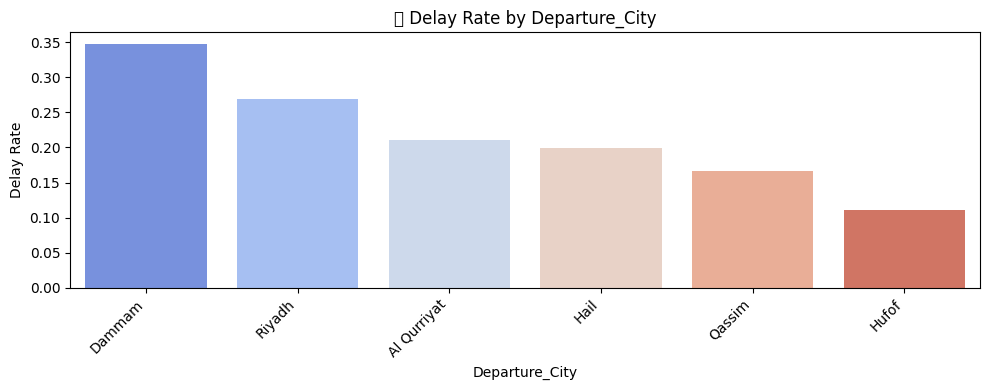

C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:107: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:111: UserWarning:

Glyph 9201 (\N{STOPWATCH}) missing from current font.

C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning:

Glyph 9201 (\N{STOPWATCH}) missing from current font.



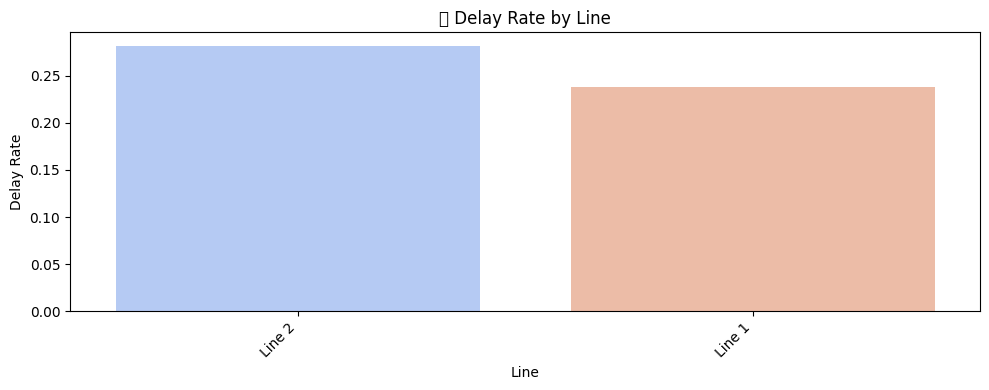

C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:107: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:111: UserWarning:

Glyph 9201 (\N{STOPWATCH}) missing from current font.

C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning:

Glyph 9201 (\N{STOPWATCH}) missing from current font.



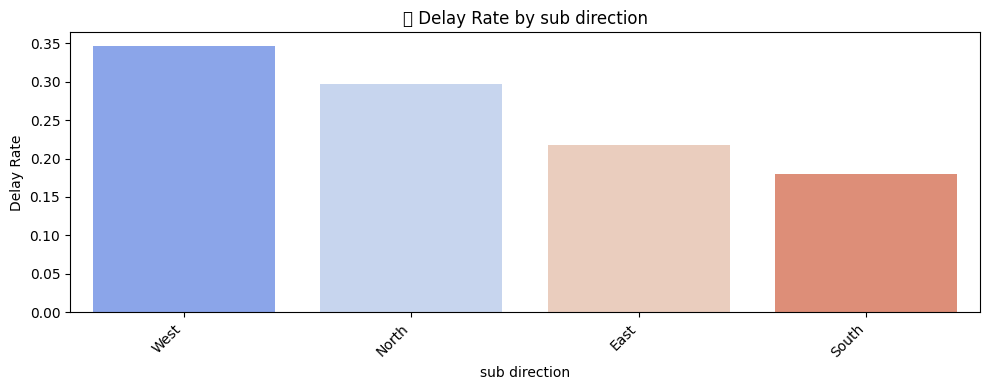

C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:107: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:111: UserWarning:

Glyph 9201 (\N{STOPWATCH}) missing from current font.

C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning:

Glyph 9201 (\N{STOPWATCH}) missing from current font.



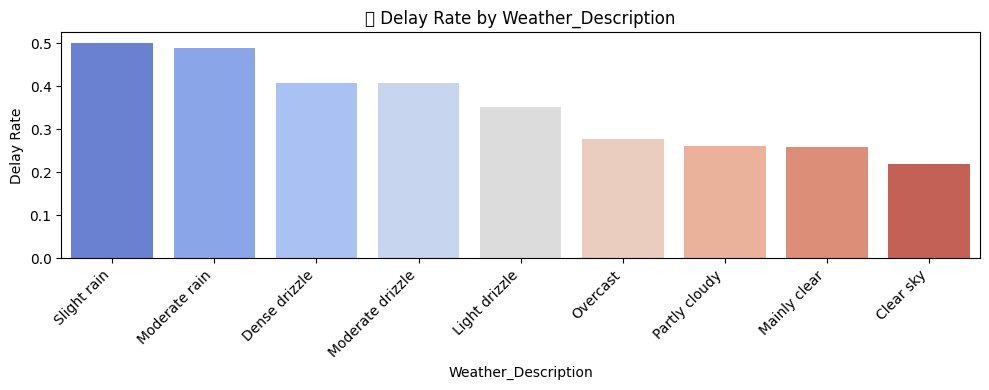

C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:107: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:111: UserWarning:

Glyph 9201 (\N{STOPWATCH}) missing from current font.

C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning:

Glyph 9201 (\N{STOPWATCH}) missing from current font.



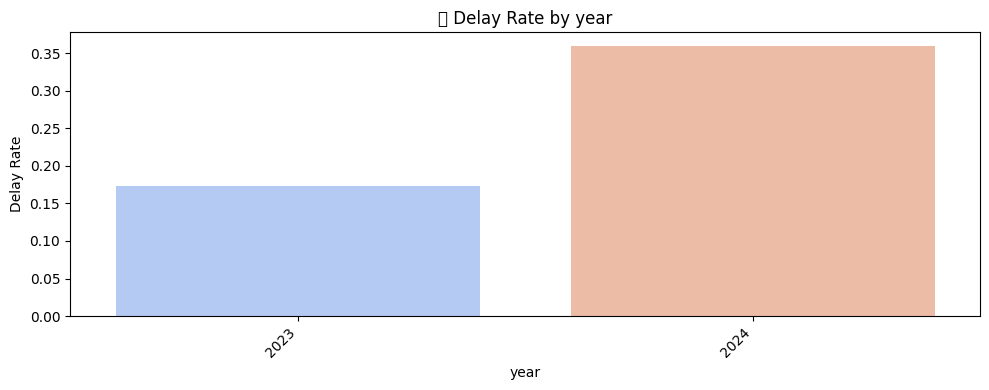

C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:120: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:120: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:120: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:120: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the sam

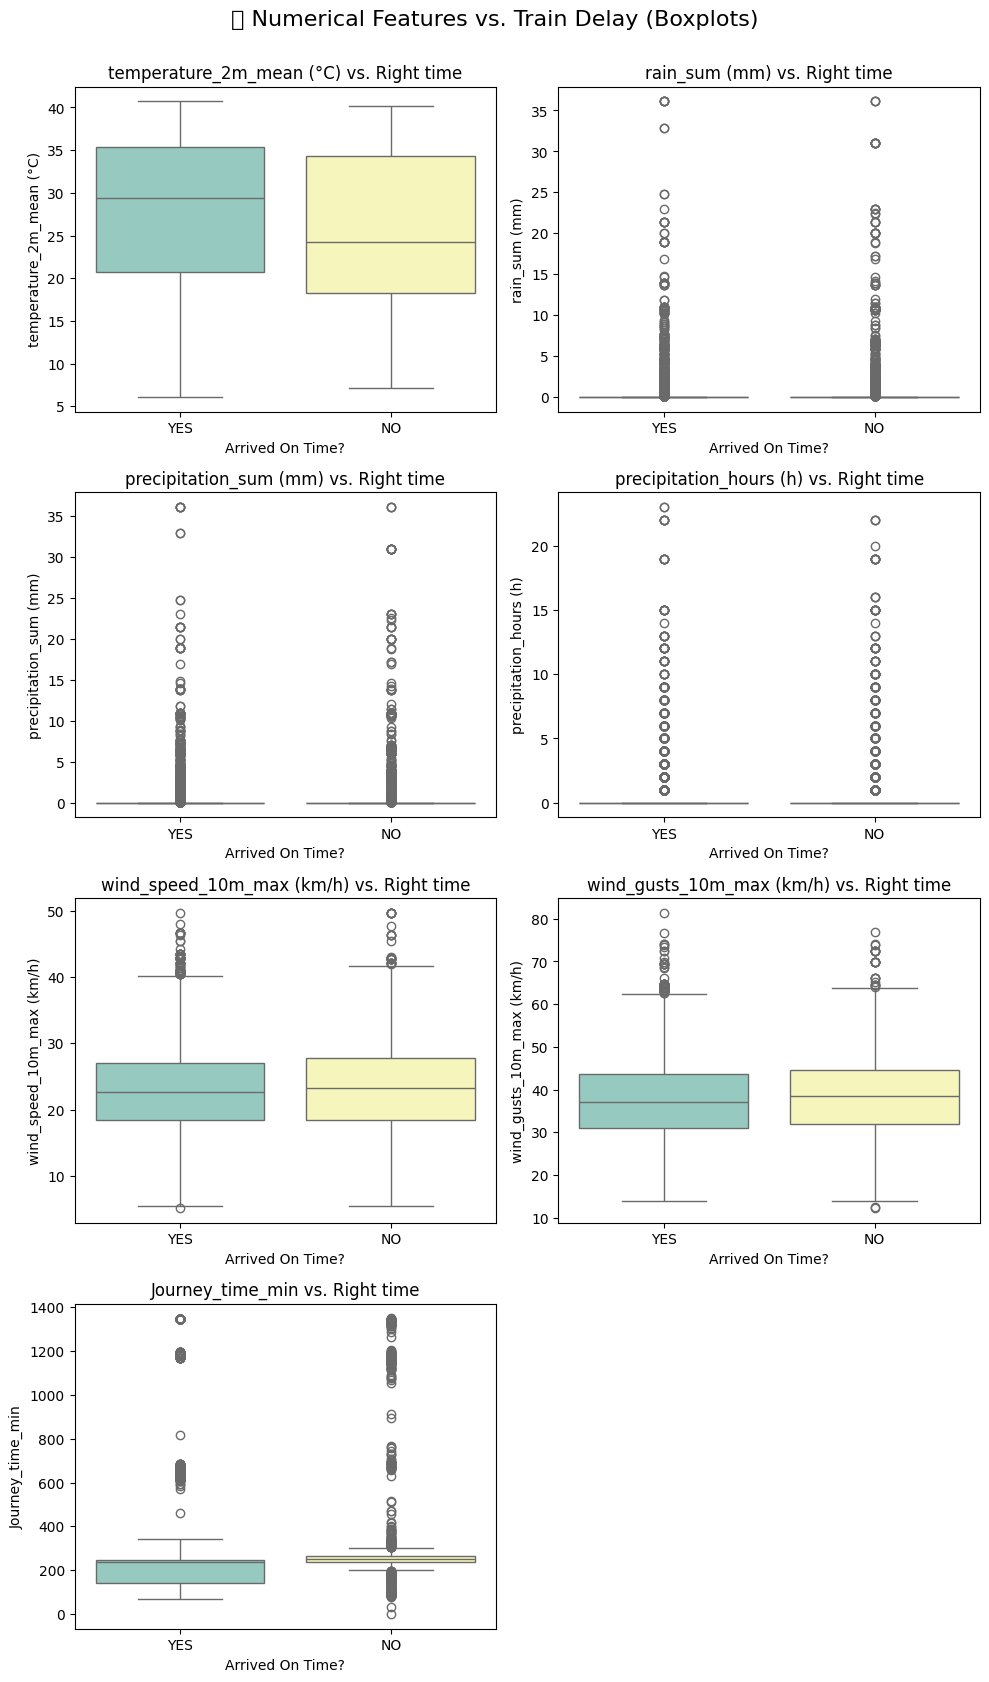

C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:170: UserWarning:

Glyph 128678 (\N{VERTICAL TRAFFIC LIGHT}) missing from current font.

C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning:

Glyph 128678 (\N{VERTICAL TRAFFIC LIGHT}) missing from current font.



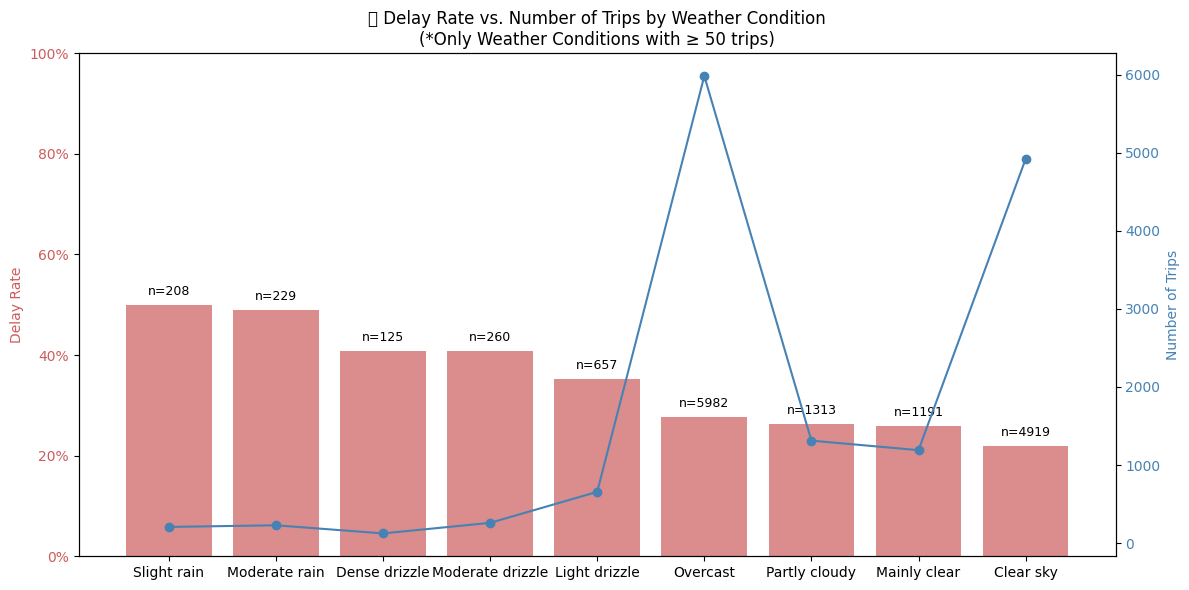

C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:185: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\user\AppData\Local\Temp\ipykernel_18468\2377913311.py:190: UserWarning:

Glyph 128678 (\N{VERTICAL TRAFFIC LIGHT}) missing from current font.

C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning:

Glyph 128678 (\N{VERTICAL TRAFFIC LIGHT}) missing from current font.



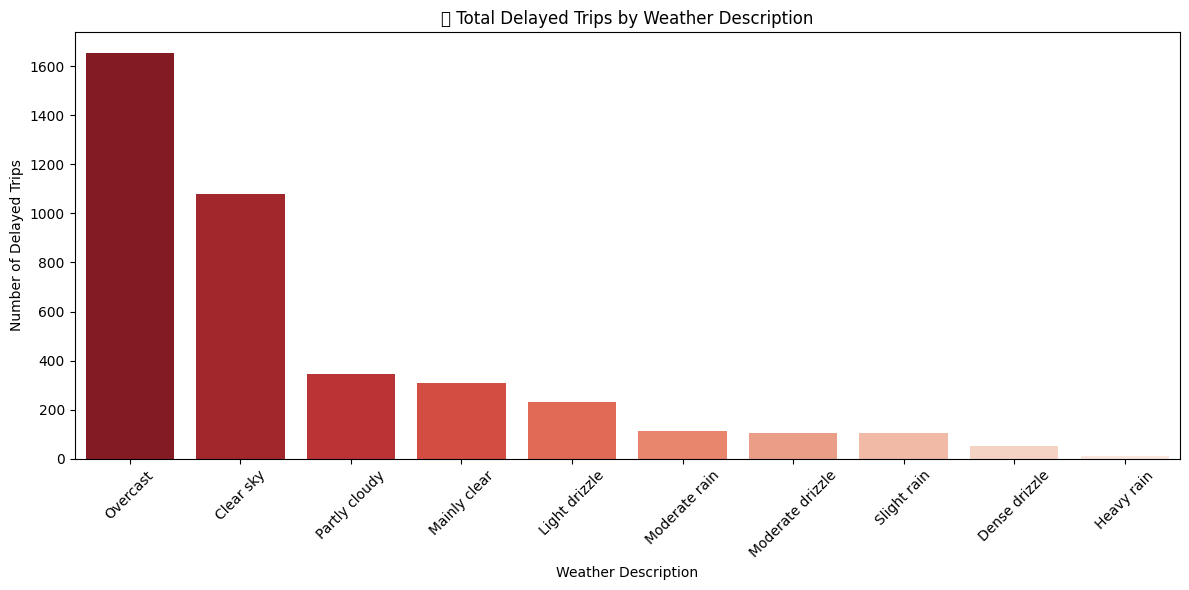

In [6]:
#===EDA===
# 1. Target Variable Exploration
plt.figure(figsize=(6, 4))
sns.countplot(data=merged_df, x='Right time', palette='Set2')
plt.title(' Target Variable Distribution (Right time)')
plt.xlabel('Arrived On Time?')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 2. Delay Category Visualization
plt.figure(figsize=(7, 4))
delay_cols = ['1-5 mins', '6-10 mins', '> 10 min']
delay_counts = (merged_df[delay_cols] == 'YES').sum()

sns.barplot(x=delay_counts.index, y=delay_counts.values, palette='viridis')
plt.title(" Distribution of Delay Categories")
plt.ylabel("Number of Trains")
plt.xlabel("Delay Category")
plt.tight_layout()
plt.show()

# 3. Numerical Feature Visualization (Histograms + Boxplots for outliers)

# === Combined Histograms ===
num_cols = true_numerical_cols
n = len(num_cols)
n_cols = 3  # Number of columns per row
n_rows = -(-n // n_cols)  # Ceiling division

plt.figure(figsize=(n_cols * 5, n_rows * 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(merged_df[col].dropna(), kde=True, color='skyblue')
    plt.title(f' Histogram: {col}')
    plt.xlabel(col)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.suptitle(" Histograms of Numerical Features", fontsize=16, y=1.02)
plt.show()

# === Combined Boxplots ===
plt.figure(figsize=(n_cols * 5, n_rows * 3.5))
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=merged_df[col], color='salmon')
    plt.title(f' Boxplot: {col}')
    plt.xlabel(col)
plt.tight_layout()
plt.suptitle(" Boxplots of Numerical Features", fontsize=16, y=1.02)
plt.show()


# === 4. Categorical Features Visualization ===

# Filter Categorical Columns (exclude binary/high-cardinality ones)
exclude_cols = ['10 PPM ', '6-10 mins', '1-5 mins', 'Right time', 'Journey time', '> 10 min']
filtered_cat_cols = [
    col for col in true_cat_cols
    if col not in exclude_cols and merged_df[col].nunique() <= 20
]

# Combined Countplots
n = len(filtered_cat_cols)
n_cols = 2
n_rows = -(-n // n_cols)  # Ceiling division

plt.figure(figsize=(n_cols * 6, n_rows * 4))
for i, col in enumerate(filtered_cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    # For 'Vacation Type', exclude 'None'
    if col == 'Vacation Type':
        plot_data = merged_df[merged_df[col] != 'None']
    else:
        plot_data = merged_df

    sns.countplot(data=plot_data, x=col, order=plot_data[col].value_counts().index, palette='pastel')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.suptitle("📊 Distribution of Selected Categorical Features", fontsize=16, y=1.02)
plt.show()

# === 5. Delay Rate Analysis by Group ===

delay_rate_cols = ['Season', 'DAY', 'Vacation Type', 'Direction', 'Departure_City', 'Line', 'sub direction', 'Weather_Description','year']
merged_df['on_time_binary'] = merged_df['Right time'].map({'YES': 1, 'NO': 0})

for col in delay_rate_cols:
    # Remove 'None' only for 'Vacation Type'
    if col == 'Vacation Type':
        df_temp = merged_df[merged_df[col] != 'None']
    else:
        df_temp = merged_df

    group_counts = df_temp[col].value_counts()
    valid_groups = group_counts[group_counts >= 50].index
    filtered_df = df_temp[df_temp[col].isin(valid_groups)]

    delay_rate = filtered_df.groupby(col)['on_time_binary'].mean().sort_values()

    plt.figure(figsize=(10, 4))
    sns.barplot(x=delay_rate.index, y=1 - delay_rate.values, palette='coolwarm')
    plt.ylabel('Delay Rate')
    plt.title(f'⏱️ Delay Rate by {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


#  Numerical Features vs Delay (Boxplots) ===

plt.figure(figsize=(n_cols * 5, n_rows * 4))
for i, col in enumerate(true_numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(data=merged_df, x='Right time', y=col, palette='Set3')
    plt.title(f'{col} vs. Right time')
    plt.xlabel('Arrived On Time?')
    plt.ylabel(col)

plt.tight_layout()
plt.suptitle("📦 Numerical Features vs. Train Delay (Boxplots)", fontsize=16, y=1.02)
plt.show()



#option 1.for weather description
import matplotlib.ticker as mtick

# Group by Weather Description with thresholds
weather_summary = (
    merged_df.groupby('Weather_Description')
    .agg(
        trip_count=('on_time_binary', 'count'),
        delay_rate=('on_time_binary', lambda x: 1 - x.mean())
    )
    .query("trip_count >= 50")  # filter out low-sample categories
    .sort_values(by='delay_rate', ascending=False)
)

# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for delay rate
color = 'indianred'
ax1.bar(weather_summary.index, weather_summary['delay_rate'], color=color, alpha=0.7)
ax1.set_ylabel("Delay Rate", color=color)
ax1.set_ylim(0, 1)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.tick_params(axis='y', labelcolor=color)

# Add trip count labels on bars
for i, val in enumerate(weather_summary['trip_count']):
    ax1.text(i, weather_summary['delay_rate'].iloc[i] + 0.02, f'n={val}', ha='center', fontsize=9)

# Line plot for trip count
ax2 = ax1.twinx()
color = 'steelblue'
ax2.plot(weather_summary.index, weather_summary['trip_count'], color=color, marker='o')
ax2.set_ylabel("Number of Trips", color=color)
ax2.tick_params(axis='y', labelcolor=color)

# Labels and layout
plt.title("🚦 Delay Rate vs. Number of Trips by Weather Condition\n(*Only Weather Conditions with ≥ 50 trips)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#option 2. for weather description
# Prepare the data
delay_summary = (
    merged_df[merged_df['Right time'] == 'NO']  # Only delayed trips
    .groupby('Weather_Description')
    .size()
    .reset_index(name='Delayed_Trips')
    .sort_values(by='Delayed_Trips', ascending=False)
)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=delay_summary, x='Weather_Description', y='Delayed_Trips', palette='Reds_r')
plt.title("🚦 Total Delayed Trips by Weather Description")
plt.xlabel("Weather Description")
plt.ylabel("Number of Delayed Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_18468\3486139988.py:60: UserWarning:

Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from current font.

C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning:

Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from current font.



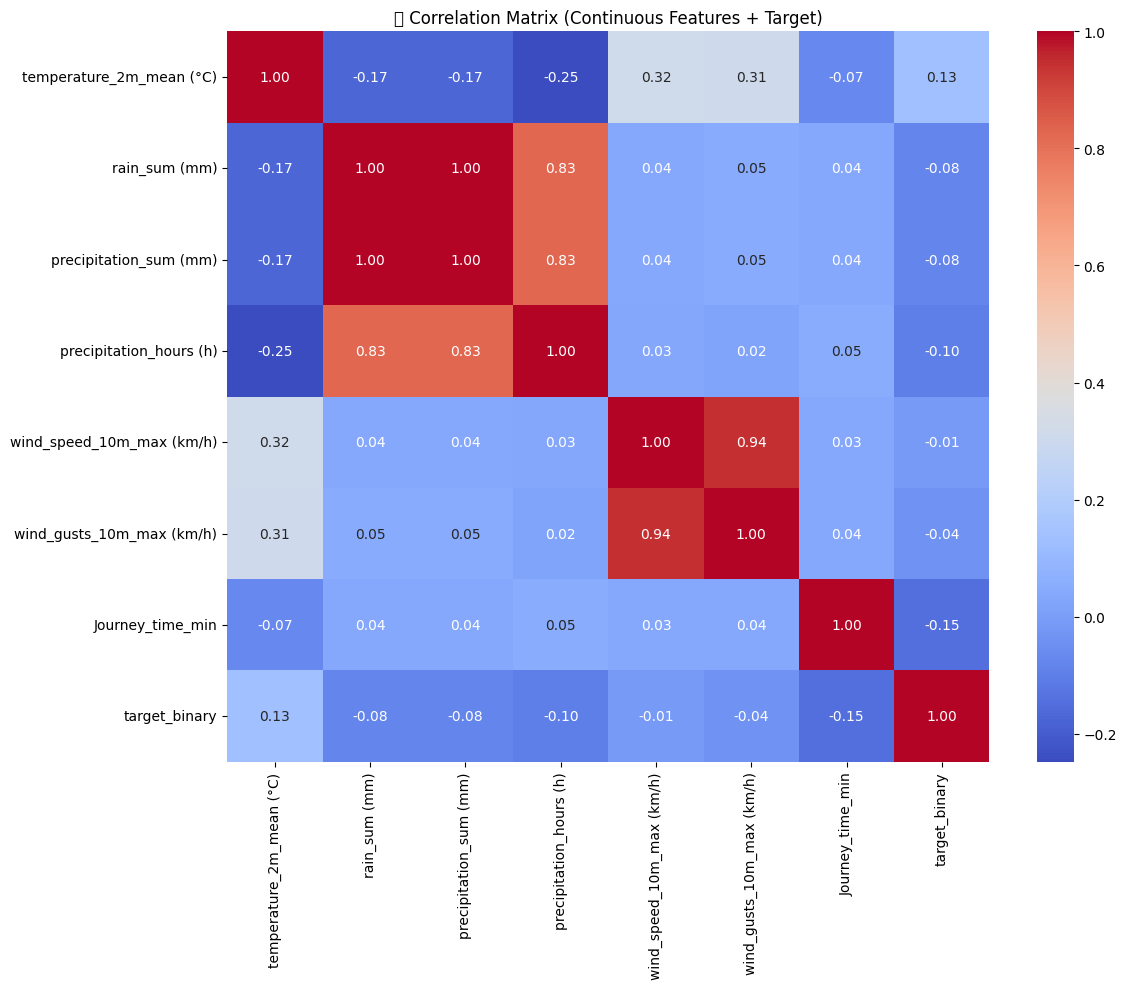

C:\Users\user\AppData\Local\Temp\ipykernel_18468\3486139988.py:84: UserWarning:

Glyph 127775 (\N{GLOWING STAR}) missing from current font.

C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning:

Glyph 127775 (\N{GLOWING STAR}) missing from current font.



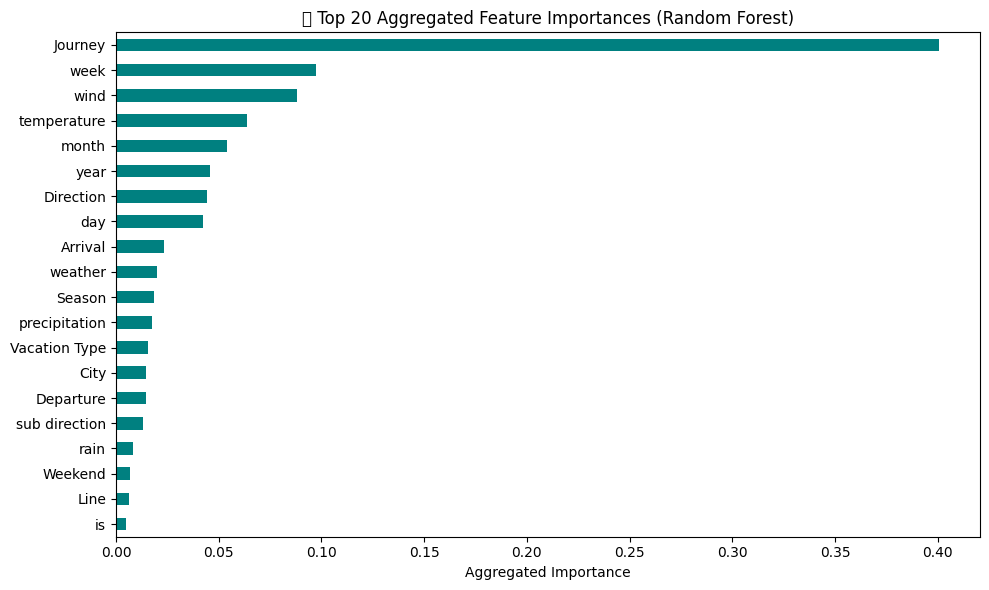


=== Permutation Importance with p-values ===
Journey_time_min               | Importance: 0.2543 | Std: 0.0028 | p-value: 0.0000
year                           | Importance: 0.0728 | Std: 0.0012 | p-value: 0.0000
temperature_2m_mean (°C)       | Importance: 0.0156 | Std: 0.0009 | p-value: 0.0000
week_sin                       | Importance: 0.0121 | Std: 0.0007 | p-value: 0.0000
month_cos                      | Importance: 0.0114 | Std: 0.0007 | p-value: 0.0000
week_cos                       | Importance: 0.0095 | Std: 0.0006 | p-value: 0.0000
wind_speed_10m_max (km/h)      | Importance: 0.0085 | Std: 0.0005 | p-value: 0.0000
wind_gusts_10m_max (km/h)      | Importance: 0.0069 | Std: 0.0005 | p-value: 0.0000
day_sin                        | Importance: 0.0059 | Std: 0.0004 | p-value: 0.0000
weather_code (wmo code)        | Importance: 0.0056 | Std: 0.0007 | p-value: 0.0000
Direction_Dammam - Riyadh      | Importance: 0.0048 | Std: 0.0005 | p-value: 0.0000
day_cos                       

In [7]:
# === Model Preprocessing ===

# 1. Select Relevant Features 
selected_features = [
    'DAY', 'Direction', 'month', 'year', 'Week Number', 'Line', 'sub direction',
    'Departure_City', 'City', 'weather_code (wmo code)', 'temperature_2m_mean (°C)',
    'rain_sum (mm)', 'precipitation_sum (mm)', 'precipitation_hours (h)',
    'wind_speed_10m_max (km/h)', 'wind_gusts_10m_max (km/h)', 'is_holiday',
    'Vacation Type', 'Journey_time_min', 'Season', 'Arrival_City', 'Weekend'
]

target = 'Right time'

# Drop missing values only from relevant features and target
model_df = merged_df[selected_features + [target]].dropna().copy()

# 2. Cyclical Encoding for Month, Week Number, and Day
# Convert DAY to numeric (Monday=0, ..., Sunday=6)
day_mapping = {
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
    'Friday': 4, 'Saturday': 5, 'Sunday': 6
}
model_df['day_num'] = model_df['DAY'].map(day_mapping)

# Encode cyclical features
model_df['month_sin'] = np.sin(2 * np.pi * model_df['month'] / 12)
model_df['month_cos'] = np.cos(2 * np.pi * model_df['month'] / 12)

model_df['week_sin'] = np.sin(2 * np.pi * model_df['Week Number'] / 53)
model_df['week_cos'] = np.cos(2 * np.pi * model_df['Week Number'] / 53)

model_df['day_sin'] = np.sin(2 * np.pi * model_df['day_num'] / 7)
model_df['day_cos'] = np.cos(2 * np.pi * model_df['day_num'] / 7)

# Drop original columns after encoding
model_df.drop(columns=['month', 'Week Number', 'DAY', 'day_num'], inplace=True)

# 3. Map target to binary
model_df['target_binary'] = model_df['Right time'].map({'YES': 1, 'NO': 0})

# 4. Encode Categorical Variables (excluding the original target)
categorical_cols = model_df.select_dtypes(include='object').columns.tolist()
categorical_cols = [col for col in categorical_cols if col != 'Right time']

# One-hot encoding
model_df_encoded = pd.get_dummies(model_df.drop(columns=['Right time']), columns=categorical_cols, drop_first=True)

# 5. Correlation Matrix (Continuous Features + Target Only)
correlation_features = [
    'temperature_2m_mean (°C)', 'rain_sum (mm)', 'precipitation_sum (mm)',
    'precipitation_hours (h)', 'wind_speed_10m_max (km/h)', 'wind_gusts_10m_max (km/h)',
    'Journey_time_min',
    'target_binary'
]

plt.figure(figsize=(12, 10))
corr_matrix = model_df_encoded[correlation_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("🔁 Correlation Matrix (Continuous Features + Target)")
plt.tight_layout()
plt.show()

# 6. Feature Importance (Aggregated)
from sklearn.ensemble import RandomForestClassifier

X = model_df_encoded.drop(columns='target_binary')
y = model_df_encoded['target_binary']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Raw importances
raw_importances = pd.Series(rf.feature_importances_, index=X.columns)

# Group by base feature (before underscores)
aggregated = raw_importances.groupby(lambda x: x.split('_')[0]).sum().sort_values(ascending=False)

# Plot top 20 groups
plt.figure(figsize=(10, 6))
aggregated.head(20).plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.title("🌟 Top 20 Aggregated Feature Importances (Random Forest)")
plt.xlabel("Aggregated Importance")
plt.tight_layout()
plt.show()

# Use the same data the model was trained on for permutation importance
perm_importance = permutation_importance(
    rf, X, y, n_repeats=30, random_state=42, n_jobs=-1
)

# Extract importances and compute p-values
feature_importance = perm_importance.importances_mean
stds = perm_importance.importances_std
p_values = (perm_importance.importances <= 0).sum(axis=1) / perm_importance.importances.shape[1]

# Print each feature's importance and its p-value
print("\n=== Permutation Importance with p-values ===")
for name, imp, std, p in sorted(zip(X.columns, feature_importance, stds, p_values), key=lambda x: -x[1]):
    print(f"{name:<30} | Importance: {imp:.4f} | Std: {std:.4f} | p-value: {p:.4f}")

#7. Feature Selection Based on Importance & Correlation  

final_selected_features = [
    'Journey_time_min',
    'week_sin', 'week_cos',
    'month_sin', 'month_cos',
    'day_sin','day_cos',
    'temperature_2m_mean (°C)',
    'wind_speed_10m_max (km/h)',
    'precipitation_sum (mm)',
    'Direction',
    'Season',
    'Vacation Type',
    'Arrival_City'

]

# Keep only selected features + target
final_df = model_df[final_selected_features + ['Right time', 'target_binary']].copy()

# Re-encode categorical columns
final_cat_cols = final_df.select_dtypes(include='object').columns.tolist()
final_cat_cols = [col for col in final_cat_cols if col != 'Right time']

final_df_encoded = pd.get_dummies(final_df.drop(columns=['Right time']), columns=final_cat_cols, drop_first=True)

# 8.Train-Test Split 
from sklearn.model_selection import train_test_split

X_final = final_df_encoded.drop(columns='target_binary')
y_final = final_df_encoded['target_binary']

X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)

print("✅ Final features used for modeling:", X_train.shape[1])
print("✅ Training set:", X_train.shape)
print("✅ Test set:", X_test.shape)


In [8]:
#===Modeling


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define models (no scalers)
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
                              use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(is_unbalance=True, random_state=42),
    'SVM': SVC(kernel='rbf', class_weight='balanced', probability=False, random_state=42)  # No probability, use decision_function
}

metrics_summary = []

for name, model in models.items():
    print(f"Evaluating {name}...")

    model.fit(X_train, y_train)

    # Train
    y_train_pred = model.predict(X_train)
    if hasattr(model, "predict_proba"):
        y_train_score = model.predict_proba(X_train)[:, 1]
    else:
        y_train_score = model.decision_function(X_train)

    # Test
    y_test_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_test_score = model.predict_proba(X_test)[:, 1]
    else:
        y_test_score = model.decision_function(X_test)

    # CV
    if hasattr(model, "predict_proba"):
        y_cv_score = cross_val_predict(model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
    else:
        y_cv_score = cross_val_predict(model, X_train, y_train, cv=cv, method='decision_function')

    y_cv_pred = cross_val_predict(model, X_train, y_train, cv=cv, method='predict')

    metrics_summary.append({
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Train ROC AUC': roc_auc_score(y_train, y_train_score),
        'CV Accuracy': accuracy_score(y_train, y_cv_pred),
        'CV ROC AUC': roc_auc_score(y_train, y_cv_score),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Test ROC AUC': roc_auc_score(y_test, y_test_score),
        'F1 Score': f1_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred),
        'Recall': recall_score(y_test, y_test_pred)
    })

results_df = pd.DataFrame(metrics_summary).sort_values(by='CV ROC AUC', ascending=False)
print("\n=== Final Model Comparison (No Scaling, Validated, With ROC AUC) ===")
print(results_df.round(4))


Evaluating Logistic Regression...


C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regr

Evaluating Random Forest...
Evaluating XGBoost...


C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[20:36:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[20:36:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[20:36:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[20:36:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


C:\Users\user\PycharmProjects\pythonProj

Evaluating LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 8722, number of negative: 3202
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002048 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 993
[LightGBM] [Info] Number of data points in the train set: 11924, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.731466 -> initscore=1.002073
[LightGBM] [Info] Start training from score 1.002073
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6978, number of negative: 2561
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000930 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you 

In [9]:
#Hyperparameter Tunning


param_grids = {

    'Random Forest': {
        'n_estimators': randint(100, 400),
        'max_depth': randint(5, 20),
        'min_samples_split': randint(2, 10),
       'min_samples_leaf': randint(1, 5),
       'max_features': ['sqrt', 'log2']  # Controls tree complexity
    },
    'XGBoost': {
      'n_estimators': randint(100, 400),
        'max_depth': randint(3, 10),
       'learning_rate': uniform(0.01, 0.15),
        'subsample': uniform(0.7, 0.3),
        'colsample_bytree': uniform(0.7, 0.3),
        'gamma': uniform(0, 5),  # Minimum loss reduction to make split
        'reg_alpha': uniform(0, 1),  # L1
        'reg_lambda': uniform(0, 1),  # L2
        'scale_pos_weight': [(y_train == 0).sum() / (y_train == 1).sum()]
},


 'LightGBM': {
    'reg_alpha': [0.1305],
    'reg_lambda': [0.1305],
    'n_estimators': [150]

 }

    
 
}

# Base models with balanced class weights
base_models = {
  
 'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
   'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(is_unbalance=True, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tuned_metrics_summary = []

# Loop through each model and tune
for name, model in base_models.items():
    print(f"Tuning {name}...")

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grids[name],
        n_iter=30,
        scoring='roc_auc',
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    # Train performance
    y_train_pred = best_model.predict(X_train)
    y_train_proba = best_model.predict_proba(X_train)[:, 1]
    train_acc = accuracy_score(y_train, y_train_pred)
    train_roc = roc_auc_score(y_train, y_train_proba)

    # CV performance
    cv_acc = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='accuracy').mean()
    cv_roc = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='roc_auc').mean()

    # Test performance
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    tuned_metrics_summary.append({
        'Model': name + ' (Tuned+Reg)',
        'Train Accuracy': train_acc,
        'Train ROC AUC': train_roc,
        'CV Accuracy': cv_acc,
        'CV ROC AUC': cv_roc,
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Test ROC AUC': roc_auc_score(y_test, y_proba),
        'F1 Score': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred)
    })

# Summary
tuned_results_df = pd.DataFrame(tuned_metrics_summary).sort_values(by='CV ROC AUC', ascending=False)
print("\n=== Tuned Model Performance Summary (with Regularization) ===")
print(tuned_results_df.round(4))


Tuning Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Tuning XGBoost...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[20:48:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[20:48:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[20:48:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\xgboost\training.py:183: UserWarning:

[20:48:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


C:\Users\user\PycharmProjects\pythonProj

Tuning LightGBM...
Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\user\PycharmProjects\pythonProject3\venv\Lib\site-packages\sklearn\model_selection\_search.py:307: UserWarning:

The total space of parameters 1 is smaller than n_iter=30. Running 1 iterations. For exhaustive searches, use GridSearchCV.



[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 8722, number of negative: 3202
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001169 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 993
[LightGBM] [Info] Number of data points in the train set: 11924, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.731466 -> initscore=1.002073
[LightGBM] [Info] Start training from score 1.002073
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6978, number of negative: 2561
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000930 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise

C:\Users\user\AppData\Local\Temp\ipykernel_18468\3685628010.py:35: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




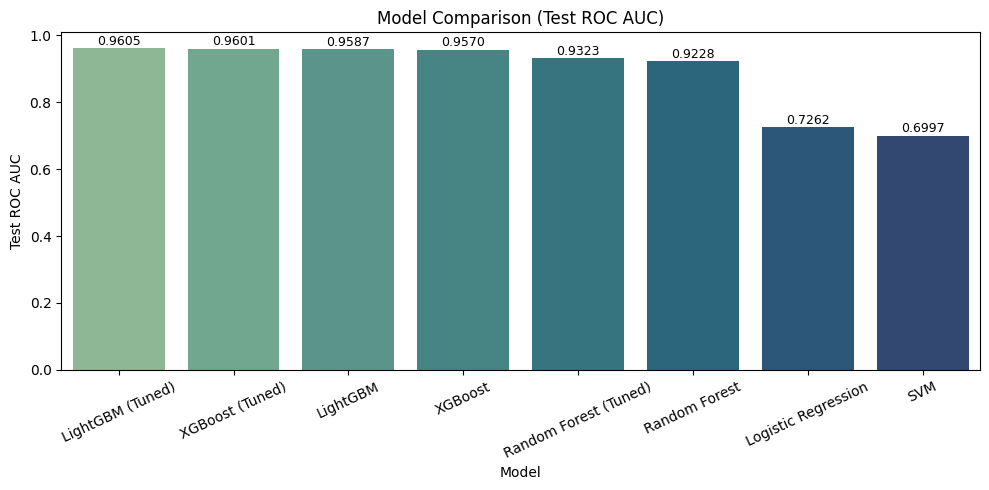

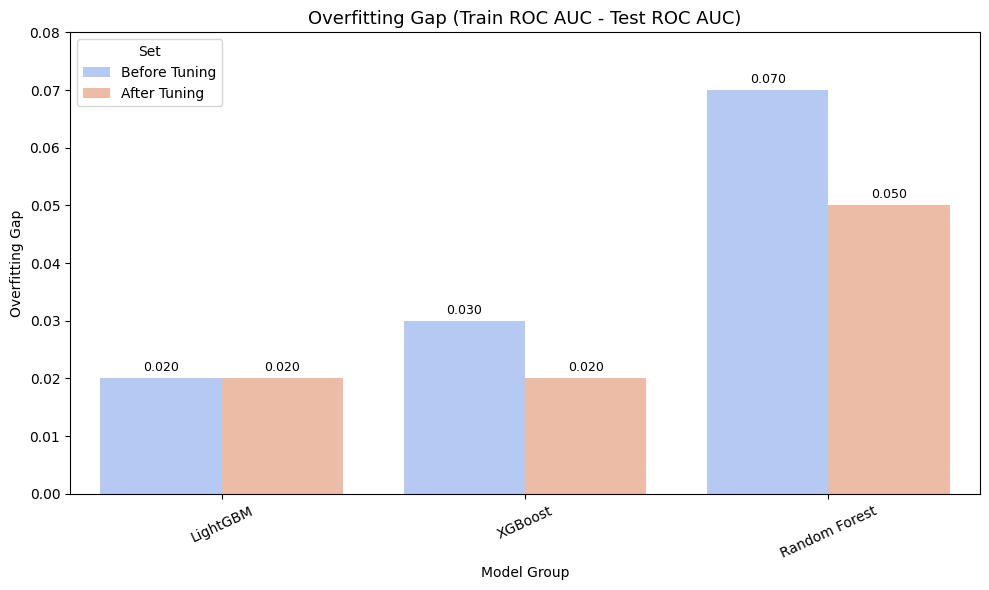


=== All Models: Test Set Metrics ===
                Model  Test Accuracy  Test ROC AUC  F1 Score  Precision  Recall
             LightGBM         0.9041        0.9587    0.9324     0.9624  0.9041
              XGBoost         0.8960        0.9570    0.9269     0.9539  0.9014
        Random Forest         0.8762        0.9228    0.9166     0.9037  0.9298
                  SVM         0.5223        0.6997    0.5759     0.8209  0.4436
  Logistic Regression         0.6481        0.7262    0.7224     0.8537  0.6261
     LightGBM (Tuned)         0.9044        0.9605    0.9327     0.9615  0.9055
      XGBoost (Tuned)         0.9004        0.9601    0.9299     0.9577  0.9037
Random Forest (Tuned)         0.8769        0.9323    0.9149     0.9254  0.9046


In [16]:
#Final Evaluation


# Final model performance BEFORE tuning
before_df = pd.DataFrame([
    {'Model': 'LightGBM', 'Train Accuracy': 0.9192, 'Train ROC AUC': 0.9807, 'CV Accuracy': 0.8888, 'CV ROC AUC': 0.9551,
     'Test Accuracy': 0.9041, 'Test ROC AUC': 0.9587, 'F1 Score': 0.9324, 'Precision': 0.9624, 'Recall': 0.9041},
    {'Model': 'XGBoost', 'Train Accuracy': 0.9459, 'Train ROC AUC': 0.9910, 'CV Accuracy': 0.8917, 'CV ROC AUC': 0.9524,
     'Test Accuracy': 0.8960, 'Test ROC AUC': 0.9570, 'F1 Score': 0.9269, 'Precision': 0.9539, 'Recall': 0.9014},
    {'Model': 'Random Forest', 'Train Accuracy': 0.9901, 'Train ROC AUC': 0.9996, 'CV Accuracy': 0.8663, 'CV ROC AUC': 0.9209,
     'Test Accuracy': 0.8762, 'Test ROC AUC': 0.9228, 'F1 Score': 0.9166, 'Precision': 0.9037, 'Recall': 0.9298},
    {'Model': 'SVM', 'Train Accuracy': 0.5265, 'Train ROC AUC': 0.7159, 'CV Accuracy': 0.5222, 'CV ROC AUC': 0.7154,
     'Test Accuracy': 0.5223, 'Test ROC AUC': 0.6997, 'F1 Score': 0.5759, 'Precision': 0.8209, 'Recall': 0.4436},
    {'Model': 'Logistic Regression', 'Train Accuracy': 0.6305, 'Train ROC AUC': 0.7097, 'CV Accuracy': 0.6271, 'CV ROC AUC': 0.7050,
     'Test Accuracy': 0.6481, 'Test ROC AUC': 0.7262, 'F1 Score': 0.7224, 'Precision': 0.8537, 'Recall': 0.6261}
])

# After tuning: only models you tuned (LightGBM, XGBoost, RF) — SVM & Logistic Regression were not tuned
after_df = pd.DataFrame([
    {'Model': 'LightGBM (Tuned)', 'Train Accuracy': 0.9353, 'Train ROC AUC': 0.9877, 'CV Accuracy': 0.8922, 'CV ROC AUC': 0.9558,
     'Test Accuracy': 0.9044, 'Test ROC AUC': 0.9605, 'F1 Score': 0.9327, 'Precision': 0.9615, 'Recall': 0.9055},
    {'Model': 'XGBoost (Tuned)', 'Train Accuracy': 0.9400, 'Train ROC AUC': 0.9887, 'CV Accuracy': 0.8915, 'CV ROC AUC': 0.9551,
     'Test Accuracy': 0.9004, 'Test ROC AUC': 0.9601, 'F1 Score': 0.9299, 'Precision': 0.9577, 'Recall': 0.9037},
    {'Model': 'Random Forest (Tuned)', 'Train Accuracy': 0.9431, 'Train ROC AUC': 0.9889, 'CV Accuracy': 0.8729, 'CV ROC AUC': 0.9298,
     'Test Accuracy': 0.8769, 'Test ROC AUC': 0.9323, 'F1 Score': 0.9149, 'Precision': 0.9254, 'Recall': 0.9046}
])
# === 1. Best Model Comparison (Test ROC AUC) ===
combined_test_auc = pd.concat([
    before_df[['Model', 'Test ROC AUC']],
    after_df[['Model', 'Test ROC AUC']]
])
combined_test_auc_sorted = combined_test_auc.sort_values(by='Test ROC AUC', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=combined_test_auc_sorted, x='Model', y='Test ROC AUC', palette='crest')
plt.title('Model Comparison (Test ROC AUC)')
plt.xticks(rotation=25)
for i, val in enumerate(combined_test_auc_sorted['Test ROC AUC']):
    plt.text(i, val + 0.001, f"{val:.4f}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# === 2. Overfitting Gap Comparison (Train AUC - Test AUC) ===

# Filter out untuned models (SVM, Logistic Regression)
before_filtered = before_df[~before_df['Model'].isin(['SVM', 'Logistic Regression'])].copy()

# Compute overfitting gaps
before_filtered['Overfitting Gap'] = before_filtered['Train ROC AUC'] - before_filtered['Test ROC AUC']
after_df['Overfitting Gap'] = after_df['Train ROC AUC'] - after_df['Test ROC AUC']

# Format labels
before_filtered['Model Group'] = before_filtered['Model']
after_df['Model Group'] = after_df['Model'].str.replace(r" \(Tuned\)", "", regex=True)

# Combine for grouped comparison
overfit_long = pd.concat([
    before_filtered[['Model Group', 'Overfitting Gap']].assign(Set='Before Tuning'),
    after_df[['Model Group', 'Overfitting Gap']].assign(Set='After Tuning')
])

# Normalize values: truncate to 2 decimal places
overfit_long['Overfitting Gap'] = (overfit_long['Overfitting Gap'] * 100).astype(int) / 100

# Optional: round for display
overfit_long['Overfitting Gap'] = overfit_long['Overfitting Gap'].round(3)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=overfit_long, x='Model Group', y='Overfitting Gap', hue='Set', palette='coolwarm')
plt.title('Overfitting Gap (Train ROC AUC - Test ROC AUC)', fontsize=13)
plt.ylabel('Overfitting Gap')
plt.ylim(0.000, 0.08)
plt.xticks(rotation=25)

# Add value labels
for container in plt.gca().containers:
    labels = [f"{v.get_height():.3f}" for v in container]
    plt.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.show()


# === 3. Test Metrics Table ===
combined_test = pd.concat([
    before_df[['Model', 'Test Accuracy', 'Test ROC AUC', 'F1 Score', 'Precision', 'Recall']],
    after_df[['Model', 'Test Accuracy', 'Test ROC AUC', 'F1 Score', 'Precision', 'Recall']]
]).reset_index(drop=True)

print("\n=== All Models: Test Set Metrics ===")
print(combined_test.round(4).to_string(index=False))
